<a href="https://colab.research.google.com/github/Arcanum241/billiard-salon-warehouse/blob/main/Netflix_Data_Ana%3Bytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/netflix_large_user_data.xlsx")
print(f"Original shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Check for missing values and duplicates
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")


Original shape: 1000 rows × 16 columns

Missing values: 0
Duplicate rows: 0


In [ ]:
# Drop irrelevant columns
df = df.drop(columns=[
    'Customer ID',
    'Churn Status (Yes/No)',
    'Payment History (On-Time/Delayed)'
])
print(f"\nDropped 3 columns. New shape: {df.shape[0]} rows × {df.shape[1]} columns")



Dropped 3 columns. New shape: 1000 rows × 13 columns


In [ ]:
# Rename columns for easier coding
df = df.rename(columns={
    'Subscription Length (Months)':        'Subscription_Length',
    'Customer Satisfaction Score (1-10)':  'Satisfaction',
    'Daily Watch Time (Hours)':           'Watch_Time',
    'Engagement Rate (1-10)':             'Engagement',
    'Device Used Most Often':             'Device',
    'Genre Preference':                   'Genre',
    'Subscription Plan':                  'Plan',
    'Support Queries Logged':             'Support_Queries',
    'Monthly Income ($)':                 'Monthly_Income',
    'Promotional Offers Used':            'Promo_Offers',
    'Number of Profiles Created':         'Profiles'
})


In [ ]:
# Show final result
print(f"\nCleaned columns: {list(df.columns)}")
df.head()


Cleaned columns: ['Subscription_Length', 'Satisfaction', 'Watch_Time', 'Engagement', 'Device', 'Genre', 'Region', 'Plan', 'Support_Queries', 'Age', 'Monthly_Income', 'Promo_Offers', 'Profiles']


,Subscription_Length,Satisfaction,Watch_Time,Engagement,Device,Genre,Region,Plan,Support_Queries,Age,Monthly_Income,Promo_Offers,Profiles
0,12,10,4.85,4,Tablet,Action,Europe,Basic,10,33,6250,5,2
1,12,8,1.75,9,Laptop,Thriller,Europe,Basic,9,28,7018,1,5
2,3,4,2.75,9,Smart TV,Comedy,Asia,Premium,3,18,1055,1,5
3,3,7,3.00,9,Smart TV,Drama,Europe,Premium,5,32,6707,5,4
4,24,2,1.37,5,Mobile,Drama,North America,Standard,2,59,1506,3,5


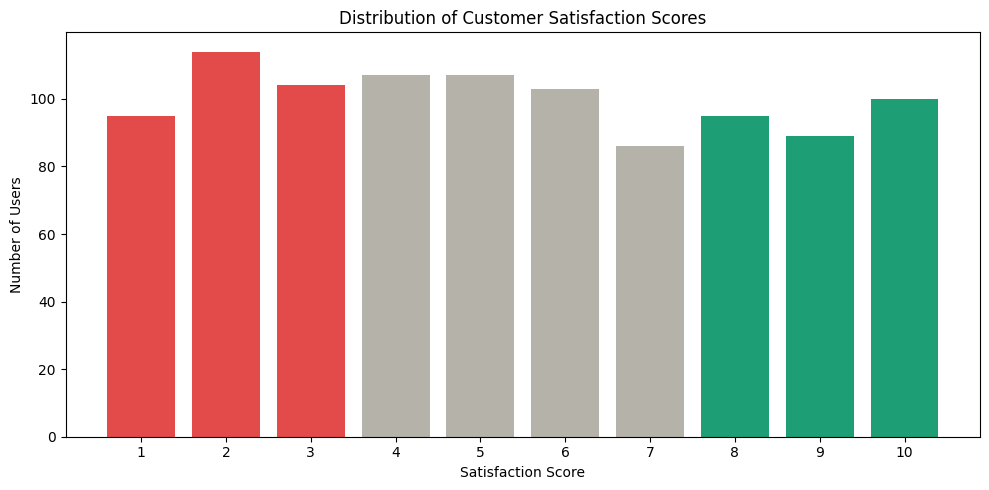

Low (1-3): 313 users (31.3%)
Mid (4-7): 403 users
High (8-10): 284 users (28.4%)


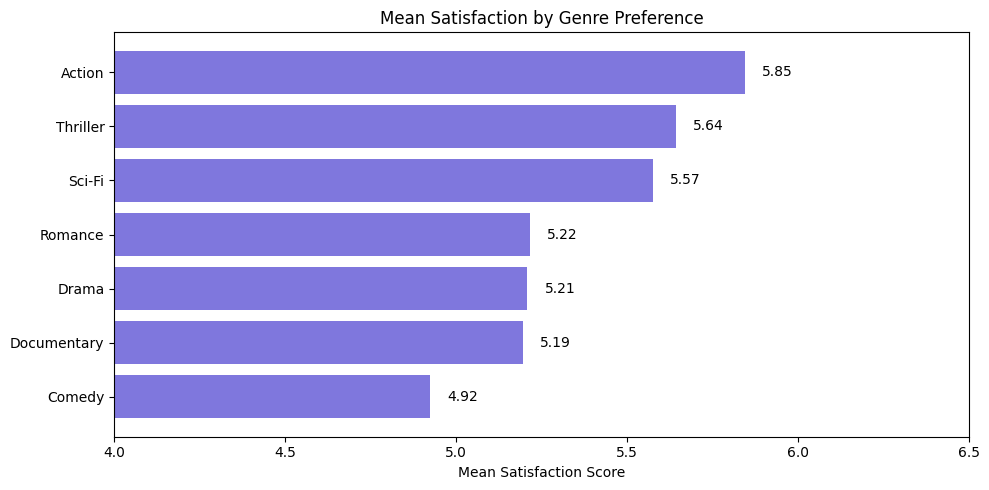

ANOVA test: F = 1.76, p = 0.1050
Action fans are the most satisfied (5.85), Comedy fans the least (4.92)


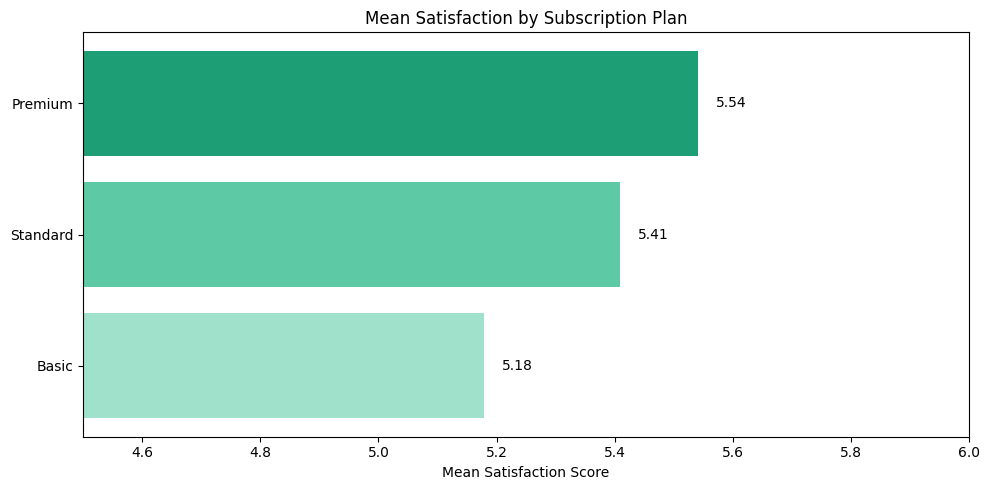

ANOVA test: F = 1.33, p = 0.2639


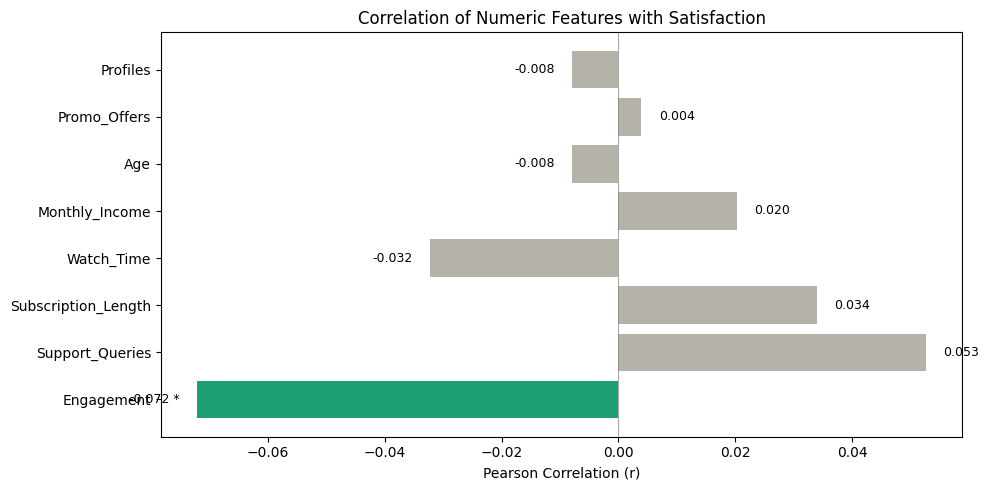

Green = statistically significant (p < 0.05)
Gray = not significant

Key finding: Engagement has a significant negative correlation (r = -0.072, p = 0.0226)


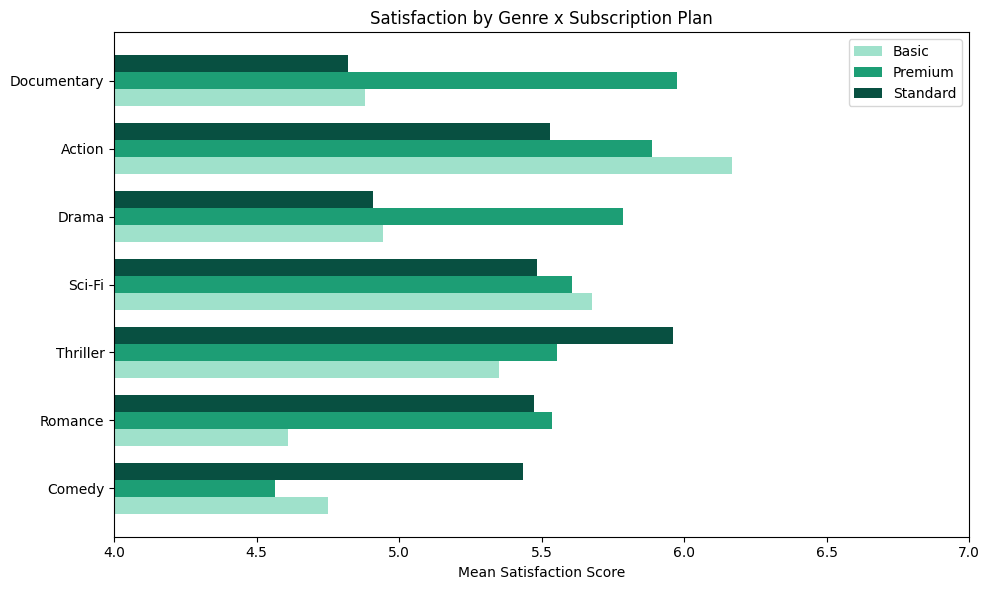

Highest cell:  Basic + Action = 6.17
Lowest cell:   Premium + Comedy = 4.56


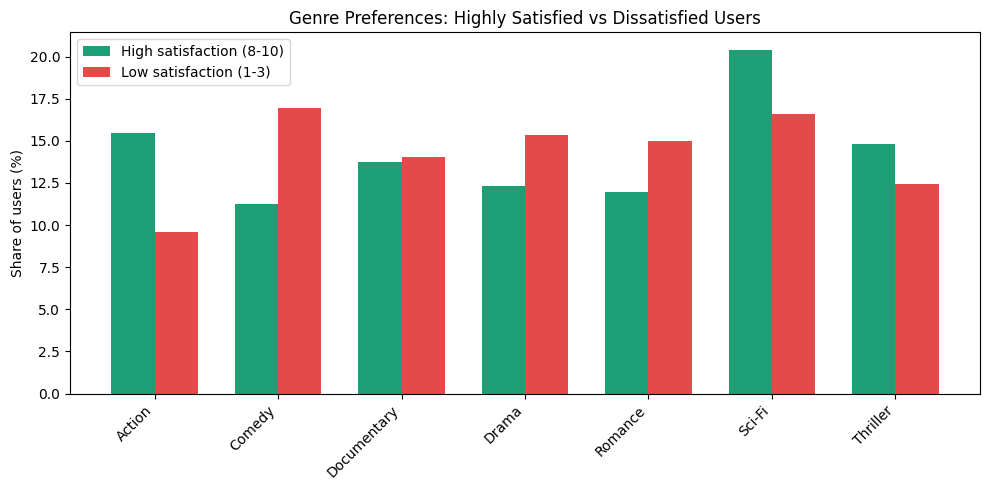

Key insight: Action is overrepresented among satisfied users (15.5% vs 9.6%)
Comedy is overrepresented among dissatisfied users (16.9% vs 11.3%)

SUMMARY OF KEY FINDINGS
1. Satisfaction is evenly distributed (no skew)
2. Action fans are the most satisfied (5.85), Comedy fans the least (4.92)
3. Premium plan users are slightly more satisfied than Basic
4. Engagement has a significant NEGATIVE correlation with satisfaction
5. Best combination: Basic plan + Action genre (mean = 6.17)
6. Action is overrepresented among happy users, Comedy among unhappy ones


In [ ]:
# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# Business Question: What combination of user traits is
# associated with the highest customer satisfaction?
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# ----------------------------------------------------------
# CHART 1: Distribution of Satisfaction Scores
# ----------------------------------------------------------
fig, ax = plt.subplots()
colors = ['#E24B4A']*3 + ['#B4B2A9']*4 + ['#1D9E75']*3
counts = df['Satisfaction'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=colors)
ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Number of Users')
ax.set_title('Distribution of Customer Satisfaction Scores')
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

print(f"Low (1-3): {len(df[df['Satisfaction'] <= 3])} users ({len(df[df['Satisfaction'] <= 3])/10:.1f}%)")
print(f"Mid (4-7): {len(df[(df['Satisfaction'] >= 4) & (df['Satisfaction'] <= 7)])} users")
print(f"High (8-10): {len(df[df['Satisfaction'] >= 8])} users ({len(df[df['Satisfaction'] >= 8])/10:.1f}%)")

# ----------------------------------------------------------
# CHART 2: Mean Satisfaction by Genre
# ----------------------------------------------------------
genre_sat = df.groupby('Genre')['Satisfaction'].mean().sort_values(ascending=True)

fig, ax = plt.subplots()
bars = ax.barh(genre_sat.index, genre_sat.values, color='#7F77DD')
ax.set_xlabel('Mean Satisfaction Score')
ax.set_title('Mean Satisfaction by Genre Preference')
ax.set_xlim(4, 6.5)

for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

f_stat, p_val = stats.f_oneway(*[g['Satisfaction'].values for _, g in df.groupby('Genre')])
print(f"ANOVA test: F = {f_stat:.2f}, p = {p_val:.4f}")
print(f"Action fans are the most satisfied (5.85), Comedy fans the least (4.92)")

# ----------------------------------------------------------
# CHART 3: Mean Satisfaction by Subscription Plan
# ----------------------------------------------------------
plan_sat = df.groupby('Plan')['Satisfaction'].mean().sort_values(ascending=True)

fig, ax = plt.subplots()
bars = ax.barh(plan_sat.index, plan_sat.values, color=['#9FE1CB', '#5DCAA5', '#1D9E75'])
ax.set_xlabel('Mean Satisfaction Score')
ax.set_title('Mean Satisfaction by Subscription Plan')
ax.set_xlim(4.5, 6)

for bar in bars:
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

f_stat, p_val = stats.f_oneway(*[g['Satisfaction'].values for _, g in df.groupby('Plan')])
print(f"ANOVA test: F = {f_stat:.2f}, p = {p_val:.4f}")

# ----------------------------------------------------------
# CHART 4: Correlation of Numeric Features with Satisfaction
# ----------------------------------------------------------
num_cols = ['Engagement', 'Support_Queries', 'Subscription_Length',
            'Watch_Time', 'Monthly_Income', 'Age', 'Promo_Offers', 'Profiles']

correlations = []
p_values = []
for col in num_cols:
    r, p = stats.pearsonr(df[col], df['Satisfaction'])
    correlations.append(r)
    p_values.append(p)

fig, ax = plt.subplots()
colors_corr = ['#1D9E75' if p < 0.05 else '#B4B2A9' for p in p_values]
bars = ax.barh(num_cols, correlations, color=colors_corr)
ax.set_xlabel('Pearson Correlation (r)')
ax.set_title('Correlation of Numeric Features with Satisfaction')
ax.axvline(x=0, color='gray', linewidth=0.5)

for bar, p in zip(bars, p_values):
    label = f'{bar.get_width():.3f}' + (' *' if p < 0.05 else '')
    ax.text(bar.get_width() + 0.003 if bar.get_width() >= 0 else bar.get_width() - 0.003,
            bar.get_y() + bar.get_height()/2, label,
            va='center', ha='left' if bar.get_width() >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("Green = statistically significant (p < 0.05)")
print("Gray = not significant")
print(f"\nKey finding: Engagement has a significant negative correlation (r = {correlations[0]:.3f}, p = {p_values[0]:.4f})")

# ----------------------------------------------------------
# CHART 5: Satisfaction by Genre x Plan (grouped bar chart)
# ----------------------------------------------------------
pivot = df.pivot_table(values='Satisfaction', index='Genre', columns='Plan', aggfunc='mean')
pivot = pivot.sort_values('Premium', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pivot.index))
width = 0.25

ax.barh(x - width, pivot['Basic'], width, label='Basic', color='#9FE1CB')
ax.barh(x, pivot['Premium'], width, label='Premium', color='#1D9E75')
ax.barh(x + width, pivot['Standard'], width, label='Standard', color='#085041')

ax.set_xlabel('Mean Satisfaction Score')
ax.set_title('Satisfaction by Genre x Subscription Plan')
ax.set_yticks(x)
ax.set_yticklabels(pivot.index)
ax.set_xlim(4, 7)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Highest cell:  Basic + Action = {pivot.loc['Action', 'Basic']:.2f}")
print(f"Lowest cell:   Premium + Comedy = {pivot.loc['Comedy', 'Premium']:.2f}")

# ----------------------------------------------------------
# CHART 6: Genre share - High vs Low satisfaction users
# ----------------------------------------------------------
high = df[df['Satisfaction'] >= 8]
low = df[df['Satisfaction'] <= 3]

high_genre = high['Genre'].value_counts(normalize=True).sort_index() * 100
low_genre = low['Genre'].value_counts(normalize=True).sort_index() * 100

genres = high_genre.index
x = np.arange(len(genres))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, high_genre.values, width, label='High satisfaction (8-10)', color='#1D9E75')
ax.bar(x + width/2, low_genre.values, width, label='Low satisfaction (1-3)', color='#E24B4A')

ax.set_ylabel('Share of users (%)')
ax.set_title('Genre Preferences: Highly Satisfied vs Dissatisfied Users')
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print("Key insight: Action is overrepresented among satisfied users (15.5% vs 9.6%)")
print("Comedy is overrepresented among dissatisfied users (16.9% vs 11.3%)")

print("\n" + "="*60)
print("SUMMARY OF KEY FINDINGS")
print("="*60)
print("1. Satisfaction is evenly distributed (no skew)")
print("2. Action fans are the most satisfied (5.85), Comedy fans the least (4.92)")
print("3. Premium plan users are slightly more satisfied than Basic")
print("4. Engagement has a significant NEGATIVE correlation with satisfaction")
print("5. Best combination: Basic plan + Action genre (mean = 6.17)")
print("6. Action is overrepresented among happy users, Comedy among unhappy ones")

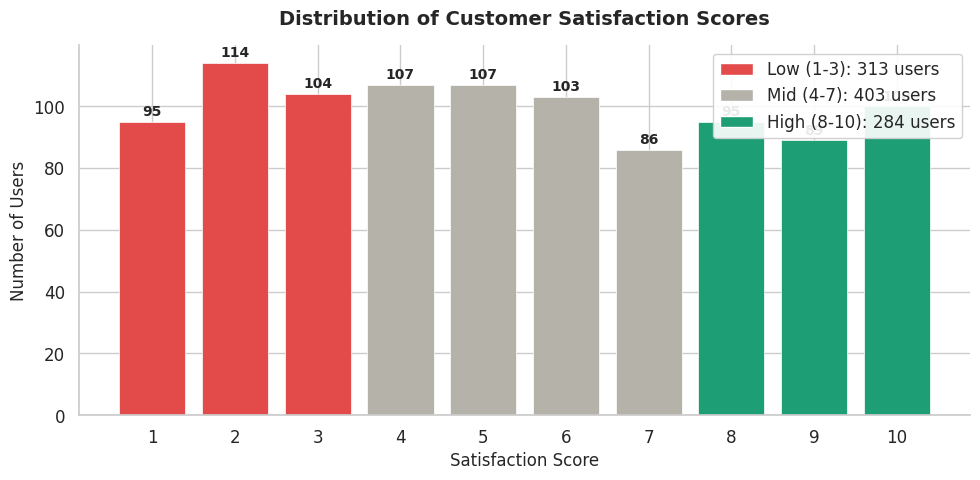

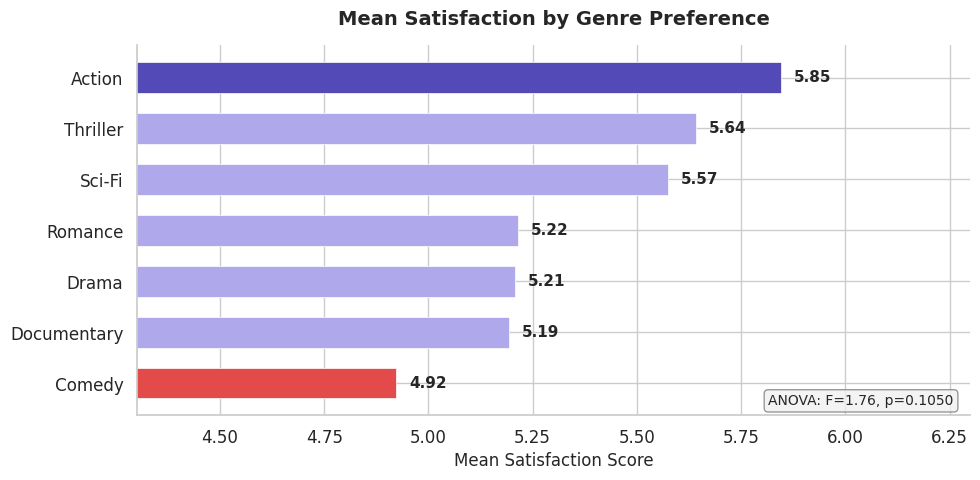

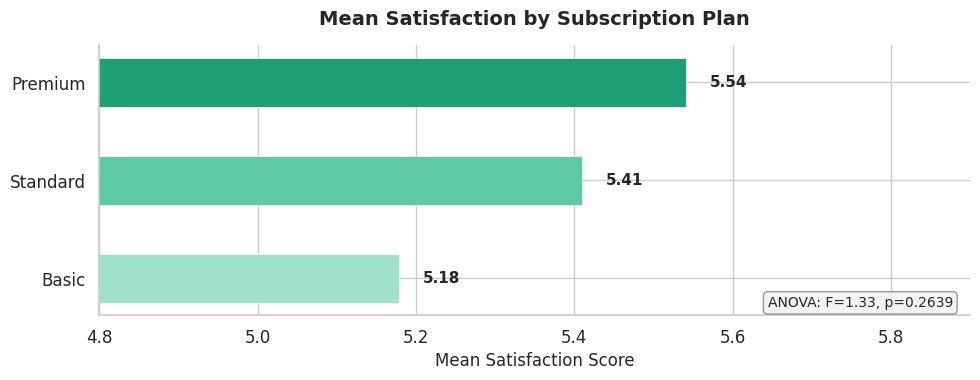

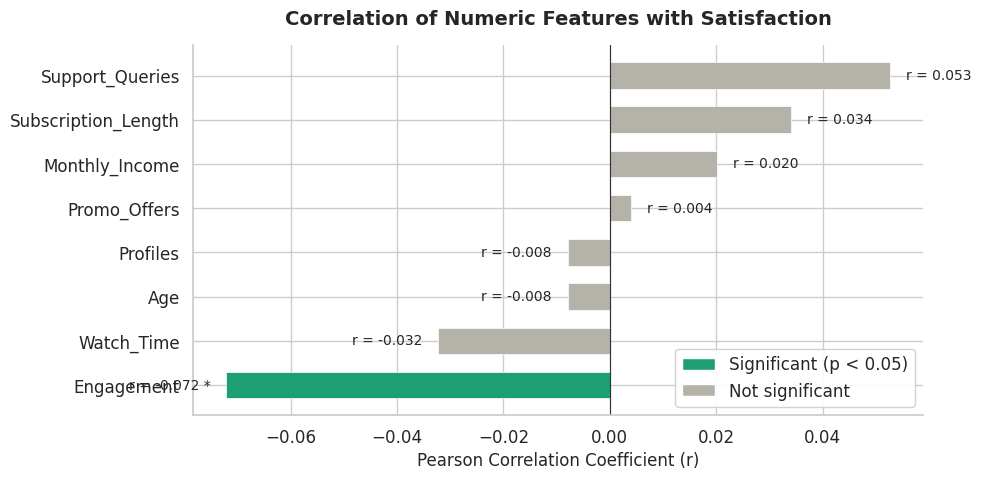

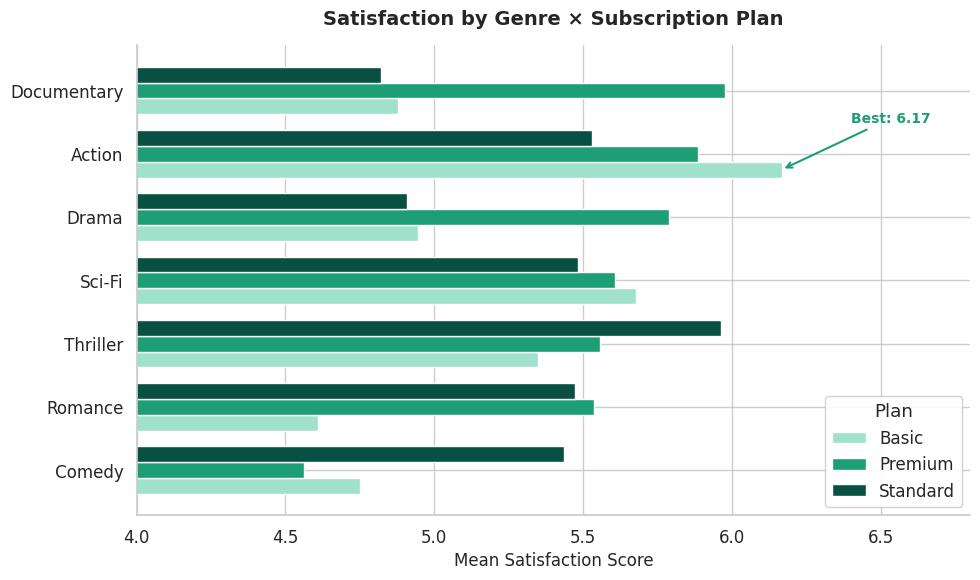

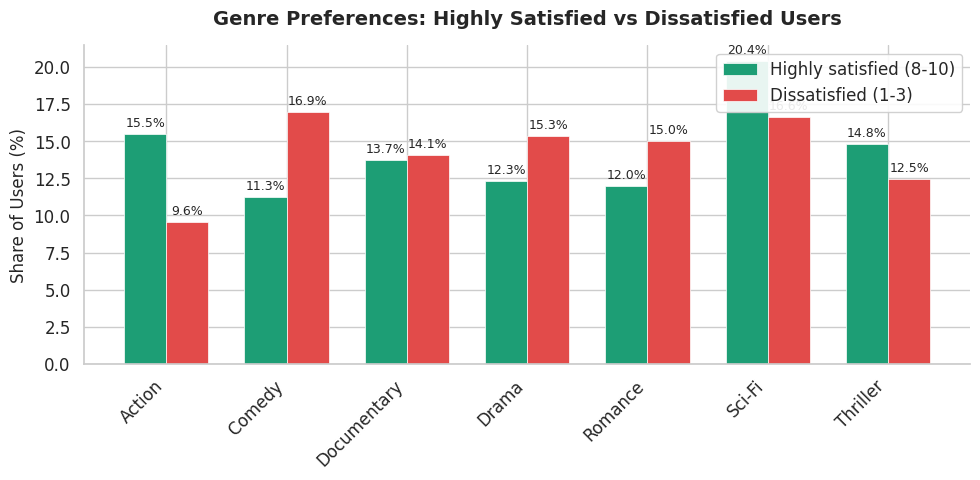


SUMMARY OF KEY FINDINGS
1. Satisfaction is evenly distributed (no skew)
2. Action fans are the most satisfied (5.85), Comedy fans the least (4.92)
3. Premium plan users are slightly more satisfied than Basic
4. Engagement has a significant NEGATIVE correlation with satisfaction
5. Best combination: Basic plan + Action genre (mean = 6.17)
6. Action is overrepresented among happy users, Comedy among unhappy ones


In [ ]:
# ============================================================
# STEP 5: FINAL VISUALIZATIONS (Seaborn + Matplotlib)
# Business Question: What combination of user traits is
# associated with the highest customer satisfaction?
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy import stats

# Professional theme
sns.set_theme(style="whitegrid", font_scale=1.1)
palette_main = ['#E24B4A', '#B4B2A9', '#1D9E75']

# ============================================================
# CHART 1: Distribution of Satisfaction Scores
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

counts = df['Satisfaction'].value_counts().sort_index()
color_map = {1:'#E24B4A', 2:'#E24B4A', 3:'#E24B4A',
             4:'#B4B2A9', 5:'#B4B2A9', 6:'#B4B2A9', 7:'#B4B2A9',
             8:'#1D9E75', 9:'#1D9E75', 10:'#1D9E75'}
bar_colors = [color_map[i] for i in counts.index]

bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Satisfaction Score', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Distribution of Customer Satisfaction Scores', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(1, 11))

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E24B4A', label=f'Low (1-3): {len(df[df["Satisfaction"] <= 3])} users'),
                   Patch(facecolor='#B4B2A9', label=f'Mid (4-7): {len(df[(df["Satisfaction"] >= 4) & (df["Satisfaction"] <= 7)])} users'),
                   Patch(facecolor='#1D9E75', label=f'High (8-10): {len(df[df["Satisfaction"] >= 8])} users')]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.show()

# ============================================================
# CHART 2: Mean Satisfaction by Genre
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

genre_sat = df.groupby('Genre')['Satisfaction'].mean().sort_values(ascending=True)
colors_genre = ['#AFA9EC'] * len(genre_sat)
colors_genre[-1] = '#534AB7'  # highest
colors_genre[0] = '#E24B4A'   # lowest

bars = ax.barh(genre_sat.index, genre_sat.values, color=colors_genre, edgecolor='white', linewidth=0.5, height=0.6)

for bar in bars:
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Mean Satisfaction Score', fontsize=12)
ax.set_title('Mean Satisfaction by Genre Preference', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(4.3, 6.3)

f_stat, p_val = stats.f_oneway(*[g['Satisfaction'].values for _, g in df.groupby('Genre')])
ax.text(0.98, 0.02, f'ANOVA: F={f_stat:.2f}, p={p_val:.4f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='gray', alpha=0.8))

sns.despine()
plt.tight_layout()
plt.show()

# ============================================================
# CHART 3: Mean Satisfaction by Subscription Plan
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))

plan_sat = df.groupby('Plan')['Satisfaction'].mean().sort_values(ascending=True)
plan_colors = ['#9FE1CB', '#5DCAA5', '#1D9E75']

bars = ax.barh(plan_sat.index, plan_sat.values, color=plan_colors, edgecolor='white', linewidth=0.5, height=0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Mean Satisfaction Score', fontsize=12)
ax.set_title('Mean Satisfaction by Subscription Plan', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(4.8, 5.9)

f_stat, p_val = stats.f_oneway(*[g['Satisfaction'].values for _, g in df.groupby('Plan')])
ax.text(0.98, 0.02, f'ANOVA: F={f_stat:.2f}, p={p_val:.4f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='gray', alpha=0.8))

sns.despine()
plt.tight_layout()
plt.show()

# ============================================================
# CHART 4: Correlation of Numeric Features with Satisfaction
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

num_cols = ['Engagement', 'Support_Queries', 'Subscription_Length',
            'Watch_Time', 'Monthly_Income', 'Age', 'Promo_Offers', 'Profiles']

corr_data = []
for col in num_cols:
    r, p = stats.pearsonr(df[col], df['Satisfaction'])
    corr_data.append({'Feature': col, 'r': r, 'p': p, 'significant': p < 0.05})

corr_data.sort(key=lambda x: x['r'])
features = [d['Feature'] for d in corr_data]
r_values = [d['r'] for d in corr_data]
bar_colors = ['#1D9E75' if d['significant'] else '#B4B2A9' for d in corr_data]

bars = ax.barh(features, r_values, color=bar_colors, edgecolor='white', linewidth=0.5, height=0.6)
ax.axvline(x=0, color='#333333', linewidth=0.8)

for bar, d in zip(bars, corr_data):
    label = f'r = {d["r"]:.3f}' + (' *' if d['significant'] else '')
    x_pos = bar.get_width() + 0.003 if bar.get_width() >= 0 else bar.get_width() - 0.003
    ha = 'left' if bar.get_width() >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, label, va='center', ha=ha, fontsize=10)

ax.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=12)
ax.set_title('Correlation of Numeric Features with Satisfaction', fontsize=14, fontweight='bold', pad=15)

legend_elements = [Patch(facecolor='#1D9E75', label='Significant (p < 0.05)'),
                   Patch(facecolor='#B4B2A9', label='Not significant')]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.show()

# ============================================================
# CHART 5: Satisfaction by Genre × Plan
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

pivot = df.pivot_table(values='Satisfaction', index='Genre', columns='Plan', aggfunc='mean')
pivot = pivot.sort_values('Premium', ascending=True)

x = np.arange(len(pivot.index))
width = 0.25

b1 = ax.barh(x - width, pivot['Basic'], width, label='Basic', color='#9FE1CB', edgecolor='white')
b2 = ax.barh(x, pivot['Premium'], width, label='Premium', color='#1D9E75', edgecolor='white')
b3 = ax.barh(x + width, pivot['Standard'], width, label='Standard', color='#085041', edgecolor='white')

ax.set_xlabel('Mean Satisfaction Score', fontsize=12)
ax.set_title('Satisfaction by Genre × Subscription Plan', fontsize=14, fontweight='bold', pad=15)
ax.set_yticks(x)
ax.set_yticklabels(pivot.index)
ax.set_xlim(4, 6.8)
ax.legend(title='Plan', loc='lower right', framealpha=0.9)

# Highlight best and worst cells
ax.annotate(f'Best: {pivot.loc["Action", "Basic"]:.2f}', xy=(pivot.loc['Action', 'Basic'], list(pivot.index).index('Action') - width),
            xytext=(6.4, len(pivot)-1.5), fontsize=10, fontweight='bold', color='#1D9E75',
            arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1.5))

sns.despine()
plt.tight_layout()
plt.show()

# ============================================================
# CHART 6: Genre Share — High vs Low Satisfaction Users
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

high = df[df['Satisfaction'] >= 8]
low = df[df['Satisfaction'] <= 3]

high_genre = high['Genre'].value_counts(normalize=True).sort_index() * 100
low_genre = low['Genre'].value_counts(normalize=True).sort_index() * 100

genres = high_genre.index
x = np.arange(len(genres))
width = 0.35

bars_h = ax.bar(x - width/2, high_genre.values, width, label='Highly satisfied (8-10)',
                color='#1D9E75', edgecolor='white', linewidth=0.5)
bars_l = ax.bar(x + width/2, low_genre.values, width, label='Dissatisfied (1-3)',
                color='#E24B4A', edgecolor='white', linewidth=0.5)

for bar in list(bars_h) + list(bars_l):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Share of Users (%)', fontsize=12)
ax.set_title('Genre Preferences: Highly Satisfied vs Dissatisfied Users', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha='right')
ax.legend(loc='upper right', framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY OF KEY FINDINGS")
print("="*60)
print("1. Satisfaction is evenly distributed (no skew)")
print("2. Action fans are the most satisfied (5.85), Comedy fans the least (4.92)")
print("3. Premium plan users are slightly more satisfied than Basic")
print("4. Engagement has a significant NEGATIVE correlation with satisfaction")
print("5. Best combination: Basic plan + Action genre (mean = 6.17)")
print("6. Action is overrepresented among happy users, Comedy among unhappy ones")